# DeepXDE Solution to 1D Heat Equation

DeepXDE is a library for scientific machine learning and physics-informed learning. DeepXDE includes the following algorithms:
* physics-informed neural network (PINN)
    * solving different problems
    * improving PINN accuracy
* (physics-informed) deep operator network (DeepONet)
* multifidelity neural network (MFNN)

Check the recent DeepXDE documentation [here](https://deepxde.readthedocs.io/en/latest/).

<center>
    <img src="images/pinn.png" width=1200 style="background-color:grey"/>
</center>

Source: deepxde.readthedocs.io


1D Heat Equation

\begin{equation}
    \begin{split}
        \frac{\partial u}{\partial t} &= k \frac{\partial^2 u}{\partial x^2} \\[2em]
    \end{split}
\end{equation}

In [1]:
#pip install deepxde

In [2]:
import deepxde as dde
from deepxde.backend import tf
import numpy as np
import matplotlib.pyplot as plt

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [3]:
# Set constants
k = 0.4         # diffusion coefficient
L = 1           # Length of the domain
n = 1           # Length of time

# Spacial domain
geom = dde.geometry.Interval(0, L)

# Temporal domain
timedomain = dde.geometry.TimeDomain(0, n)

geomtime = dde.geometry.GeometryXTime(geom, timedomain)

In [4]:
# Define initial condition (IC)
ic = dde.icbc.IC(geomtime, 
                 lambda x: np.sin(n*np.pi*x[:, 0:1]/L), 
                 lambda _, 
                 on_initial:on_initial)             # on_initial:on_initial --> lambda function will only be applied to IC

Short intro to lambda functions

In [5]:
# Short intro to lambda functions
input_array = np.array([[1, 2, 3],
                        [4, 5, 6],
                        [7, 8, 9]])

# Note no 'def' needed
lambda_function = lambda x : 2*x[:, 0:1]            # From all rows (:) of the input, get the first value (0:1, i.e. from 0 to 1, where 1 is exclusive) and multiply it by 2 

result_array = lambda_function(input_array)
#print(result_array)

# Conditional lambda functions
cond_lambda = lambda x : "Even" if x%2 == 0 else "Odd"
#print(cond_lambda(4))
#print(cond_lambda(3))

In [6]:
def double_first_column(input_array):
    print("input_array", input_array)
    print("input_array.shape", input_array.shape)
    print("input_array[:, 0:1]", input_array[:, 0:1])
    print("input_array[:, 0:1].shape", input_array[:, 0:1].shape)
    print("input_array[:, 0]", input_array[:, 0])
    print("input_array[:, 0].shape", input_array[:, 0].shape)
    return 2 * input_array[:, 0:1]

# Define boundary condition (BC)
bc = dde.icbc.DirichletBC(geomtime, 
                          lambda input_array: double_first_column(input_array),
                          lambda _,
                          on_boundary:on_boundary
                         )

## Define the network and the PDE

### Calculate derivatives using the deepxde.gradients.gradients module

__First Order Derivatives__

$\,\,$ _deepxde.gradients.gradients.jacobian(ys, xs, i=None, j=None)_

$\,\,$ Compute Jacobian matrix $J$ as $J[i, j] = dy_i / dx_j$, where $i = 0, …, dim_y - 1$ and $j = 0, …, dim_x - 1$.

$\,\,$ Use this function to compute first-order derivatives instead of $\,\,$ _tf.gradients()_ $\,\,$ or $\,\,$ _torch.autograd.grad()_, $\,\,$ because
* It is lazy evaluation, i.e., it only computes $J[i, j]$ when needed.
* It will remember the gradients that have already been computed to avoid duplicate computation.



__Second Order Derivatives__

$\,\,$ _deepxde.gradients.gradients.hessian(ys, xs, component=0, i=0, j=0)_

$\,\,$ Compute Hessian matrix $H$ as $H[i, j] = d^2y / dx_i dx_j$, where $i,j = 0, …, dim_x - 1$.

$\,\,$ Use this function to compute second-order derivatives instead of $\,\,$ _tf.gradients()_ $\,\,$ or $\,\,$ _torch.autograd.grad()_, $\,\,$ because
* It is lazy evaluation, i.e., it only computes $H[i, j]$ when needed.
* It will remember the gradients that have already been computed to avoid duplicate computation.

In [7]:
# PDE for 1D heat equation given some computational space: j=0: x, j=1: t
def pde(comp_space, u):
    # Calculate First Order Derivative using jacobian()
    du_t = dde.grad.jacobian(u,                     # Output Tensor of shape (batch_size, dim_y)
                             comp_space,            # Input Tensor of shape (batch_size, dim_x)
                             i=0,                   # i-th row. If i=None, returns the j-th column J[:, j].
                             j=1                    # j-th column. If j=None, returns the i-th row J[`i, :], i.e., the gradient of y_i. i and j cannot be both None, unless J has only one element, which is returned.
                            )                       # Returns: H[i, j] 

    # Calculate Second order Derivative using hessian()
    du_xx = dde.grad.hessian(u,                     # Output Tensor of shape (batch_size, dim_y)
                             comp_space,            # Input Tensor of shape (batch_size, dim_x)
                             i=0,                   # i-th row
                             j=0                    # j-th column
                            )

    # Return the residual
    return du_t - k*du_xx                           # See formula for 1D heat equation above

In [30]:
# Define the actual data to be trained
data = dde.data.TimePDE(geomtime,
                        pde,
                        [bc, ic],
                        num_domain = 2540,          # number of points sampled in the domain
                        num_boundary = 80,          # number of points sampled for the boundary condition (i.e. along the y-axis)
                        num_initial = 160,          # number of points sampled for the initial condition (i.e. along the x-axis)
                        num_test = 2540,
                       )

c:\Users\kunst\AppData\Local\anaconda3\envs\torchenv\Lib\site-packages\skopt\space\space.py:111: UserWarning: Dimension (0.0, 1.0) was inferred to Real(low=0.0, high=1.0, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to <TypeError: Real.__init__() got an unexpected keyword argument 'tranform'>. See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
c:\Users\kunst\AppData\Local\anaconda3\envs\torchenv\Lib\site-packages\skopt\space\space.py:111: UserWarning: Dimension (0.0, 1.0) was inferred to Real(low=0.0, high=1.0, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to <TypeError: Real.__init__() got an unexpected keyword argument 'tranform'>. See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
c:\Users\kunst\AppData\Local\anaconda3\envs\torchenv\Lib\site-packages\skopt\space\space.py:111: UserWarning: Di

In [31]:
# Define the network, in this case we use a Forward Neural Network (FNN)
net = dde.nn.FNN([2] + 3*[20] + [1],                # 2 input nodes, 3 layers with 20 nodes each, 1 output node
                 "tanh",                            # activation function
                 "Glorot normal"                    # random initialization of network weights but with mean=0
                )

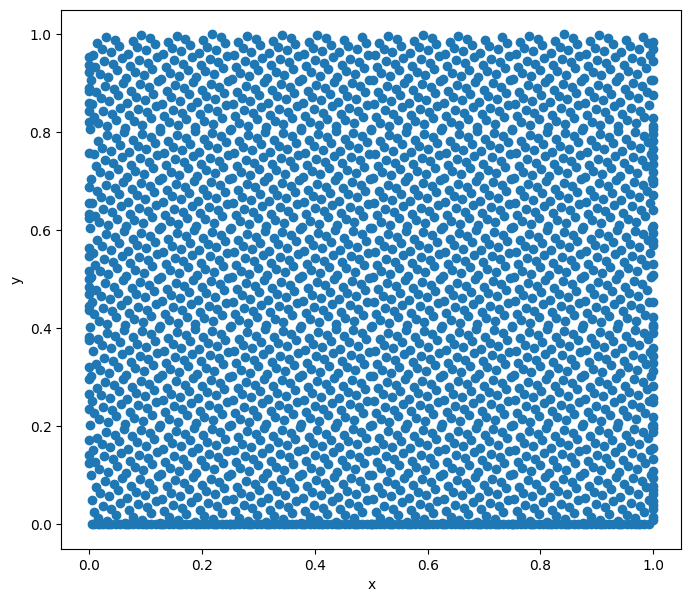

In [32]:
# Plot the computational domain
## Note: PINNs are a meshless methode, i.e. there is no grid
plt.figure(figsize=(8, 7))
plt.scatter(data.train_x_all[:, 0],                 # values of x
            data.train_x_all[:, 1])                 # equivalent values of y
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In the above plot the number of points
* within the domain is defined by ___num_domain___,
* on the boundary condition, along the y-axis (i.e. x=0 or x=1), is defined by ___num_boundary___,
* on the initial condition, along the x-axis (i.e. y=0), ___num_initial___.

## Train the model

In [11]:
# Initialize the model
model = dde.Model(data, net)

In [12]:
# Set optimizer and learning rate (lr)
model.compile("adam",                               # Adam is an algorithm for first-order gradient-based optimization of stochastic objective functions to iteratively update network weights based on training data
              lr=1e-3)

Compiling model...
'compile' took 0.306085 s



In [13]:
# Train the model
losshistory, train_state = model.train(iterations = 15000)

Training model...

input_array [[1.        0.625    ]
 [1.        0.421875 ]
 [1.        0.46875  ]
 [0.        0.890625 ]
 [0.        0.234375 ]
 [1.        0.3203125]
 [1.        0.359375 ]
 [1.        0.75     ]
 [0.        0.9375   ]
 [0.        0.671875 ]
 [0.        0.5625   ]
 [0.        0.046875 ]
 [1.        0.171875 ]
 [1.        0.828125 ]
 [1.        0.328125 ]
 [1.        0.8125   ]
 [1.        0.6953125]
 [1.        0.28125  ]
 [0.        0.15625  ]
 [0.        0.0625   ]
 [0.        0.546875 ]
 [0.        0.6875   ]
 [0.        0.6328125]
 [1.        0.4375   ]
 [1.        0.515625 ]
 [1.        0.796875 ]
 [0.        0.71875  ]
 [1.        0.109375 ]
 [0.        0.65625  ]
 [1.        0.765625 ]
 [1.        0.859375 ]
 [0.        0.1953125]
 [0.        0.0078125]
 [0.        0.734375 ]
 [0.        0.59375  ]
 [1.        0.078125 ]
 [0.        0.90625  ]
 [0.        0.2578125]
 [0.        0.125    ]
 [0.        0.78125  ]
 [1.        0.609375 ]
 [1.        0.3125   ]
 [1

1000      [1.08e-02, 3.46e-02, 4.12e-02]    [7.38e-03, 3.46e-02, 4.12e-02]    []  
2000      [3.00e-03, 1.34e-02, 7.67e-03]    [1.73e-03, 1.34e-02, 7.67e-03]    []  
3000      [4.15e-03, 6.53e-03, 3.33e-03]    [3.00e-03, 6.53e-03, 3.33e-03]    []  
4000      [1.29e-03, 2.97e-03, 2.03e-03]    [9.45e-04, 2.97e-03, 2.03e-03]    []  
5000      [8.98e-03, 1.42e-03, 2.37e-03]    [6.51e-03, 1.42e-03, 2.37e-03]    []  
6000      [8.90e-04, 1.16e-03, 9.10e-04]    [6.56e-04, 1.16e-03, 9.10e-04]    []  
7000      [7.12e-04, 9.24e-04, 6.52e-04]    [5.25e-04, 9.24e-04, 6.52e-04]    []  
8000      [6.30e-04, 7.44e-04, 4.63e-04]    [4.73e-04, 7.44e-04, 4.63e-04]    []  
9000      [5.50e-04, 5.95e-04, 3.68e-04]    [4.11e-04, 5.95e-04, 3.68e-04]    []  
10000     [5.19e-04, 4.89e-04, 3.22e-04]    [3.88e-04, 4.89e-04, 3.22e-04]    []  
11000     [4.54e-04, 4.15e-04, 2.85e-04]    [3.37e-04, 4.15e-04, 2.85e-04]    []  
12000     [4.11e-04, 3.66e-04, 2.54e-04]    [3.07e-04, 3.66e-04, 2.54e-04]    []  
1300

In [33]:
# Use L-BFGS-B for better accuracy
model.compile("L-BFGS-B")                           # Limited-memory Broyden-Fletcher-Goldfarb-Shanno
losshistory, train_state = model.train()

Compiling model...
'compile' took 0.000989 s

Training model...

20157     [3.19e-04, 2.72e-04, 2.04e-04]    [2.40e-04, 2.72e-04, 2.04e-04]    []  
20160     [3.19e-04, 2.72e-04, 2.04e-04]    [2.40e-04, 2.72e-04, 2.04e-04]    []  
20161     [3.19e-04, 2.72e-04, 2.04e-04]    [2.40e-04, 2.72e-04, 2.04e-04]    []  
20162     [3.19e-04, 2.72e-04, 2.04e-04]    [2.40e-04, 2.72e-04, 2.04e-04]    []  
20163     [3.19e-04, 2.72e-04, 2.04e-04]    [2.40e-04, 2.72e-04, 2.04e-04]    []  
20164     [3.19e-04, 2.72e-04, 2.04e-04]    [2.40e-04, 2.72e-04, 2.04e-04]    []  
20165     [3.19e-04, 2.72e-04, 2.04e-04]    [2.40e-04, 2.72e-04, 2.04e-04]    []  
20166     [3.19e-04, 2.72e-04, 2.04e-04]    [2.40e-04, 2.72e-04, 2.04e-04]    []  
20167     [3.19e-04, 2.72e-04, 2.04e-04]    [2.40e-04, 2.72e-04, 2.04e-04]    []  
20168     [3.19e-04, 2.72e-04, 2.04e-04]    [2.40e-04, 2.72e-04, 2.04e-04]    []  
20169     [3.19e-04, 2.72e-04, 2.04e-04]    [2.40e-04, 2.72e-04, 2.04e-04]    []  
20170     [3.19e-04, 2

KeyboardInterrupt: 

Saving loss history to c:\Users\kunst\VSC\Udemy\ML\Physics Informed Neural Networks (PINNs)\6 DeepXDE Solution for 1D Heat\loss.dat ...
Saving training data to c:\Users\kunst\VSC\Udemy\ML\Physics Informed Neural Networks (PINNs)\6 DeepXDE Solution for 1D Heat\train.dat ...
Saving test data to c:\Users\kunst\VSC\Udemy\ML\Physics Informed Neural Networks (PINNs)\6 DeepXDE Solution for 1D Heat\test.dat ...


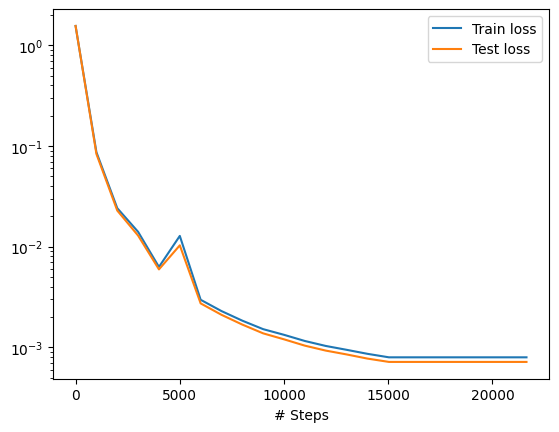

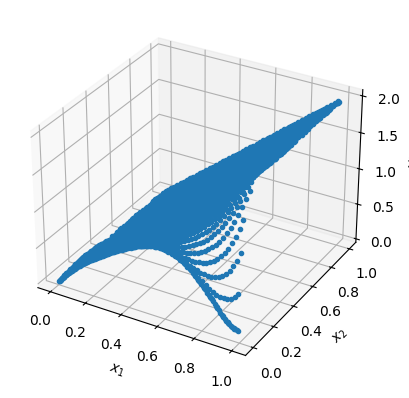

In [34]:
# Save result plot
dde.saveplot(losshistory, train_state, issave= True, isplot=True)